In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns

backtest_data = '../../data/backtest/backtest_results_20250101_20261204.csv'
df = pd.read_csv(backtest_data)
df.columns

/var/folders/jk/b5tnwh1j1hq90nsy6xg8w2_h0000gn/T/ipykernel_82086/2842964580.py:9: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(backtest_data)


Index(['date', 'scode', 'Future_High_Tac', 'Future_Low_Tac',
       'Future_Close_Tac', 'Future_High_Str', 'Future_Low_Str',
       'Future_Close_Str', 'scores_GANDALF_target_str_gauss_rank',
       'scores_GANDALF_target_tac_gauss_rank',
       'scores_LightGBM_target_str_gauss_rank',
       'scores_LightGBM_target_str_triple_barrier',
       'scores_LightGBM_target_tac_gauss_rank',
       'scores_LightGBM_target_tac_tb_strategy_a',
       'scores_TCN_target_tac_vol_scaled_residual',
       'scores_TabNet_target_str_gauss_rank',
       'scores_TabNet_target_tac_gauss_rank'],
      dtype='object')

In [44]:
df.groupby(['date']).size().tail(40)

date
2025-12-18    4144
2025-12-19    4145
2025-12-22    4145
2025-12-23    4145
2025-12-24    4143
2025-12-25    4132
2025-12-26    4133
2025-12-29    4134
2025-12-30    4134
2026-01-05    4135
2026-01-06     102
2026-01-07     102
2026-01-08     102
2026-01-09     102
2026-01-13     100
2026-01-14     100
2026-01-15     100
2026-01-16     100
2026-01-19     100
2026-01-20     100
2026-01-21     100
2026-01-22     100
2026-01-23     100
2026-01-26     100
2026-01-27     100
2026-01-28      98
2026-01-29      98
2026-01-30      98
2026-02-02      98
2026-02-03      98
2026-02-04      98
2026-02-05      98
2026-02-06      98
2026-02-09      98
2026-02-10      98
2026-02-12      98
2026-02-13      98
2026-02-16      98
2026-02-17      98
2026-02-18      98
dtype: int64

## RankIC & Quantile分析

In [36]:

def evaluate_model_performance(df, score_col, target_col, n_bins=5, horizon=5, save_dir=None):
    """
    Rank ICの算出およびクオンタイル分析を実行する
    Args:
        df (pd.DataFrame): 'date', 'scode', score_col, target_col を含むDF
        score_col (str): モデルの予測スコア列名
        target_col (str): リターン（価格比）の列名 (例: Future_Close_Tac)
        n_bins (int): クオンタイル分割数
        horizon (int): 予測期間 (5 or 60)
        save_dir (str, optional): グラフを保存するディレクトリのパス
    Returns:
        pd.DataFrame: 日付ごとの対象件数、daily_ic、各クオンタイルの累積リターンを含む明細データフレーム
    """
    df = df[['date', 'scode', score_col, target_col]].dropna(subset=[score_col, target_col]).copy()
    # 前処理: リターンをログリターンに変換
    df['log_return'] = np.log(df[target_col])

    # --- 日別スコア上位10銘柄の評価 ---
    print(f"🏆 Calculating Top 10 Metrics for {score_col}...")
    def get_top10_metrics(group):
        top10 = group.nlargest(10, score_col)
        return pd.Series({
            'top10_min_score': top10[score_col].min(),
            'top10_mean_return': top10[target_col].mean()
        })
    top10_metrics = df.groupby('date').apply(get_top10_metrics)

    # Rank IC の算出 
    print(f"📊 Calculating Rank IC for {score_col}...")
    def calc_daily_ic(group):
        # スピアマンの順位相関係数
        ic, _ = stats.spearmanr(group[score_col], group['log_return'])
        return ic
    daily_ic = df.groupby('date').apply(calc_daily_ic)
    mean_ic = daily_ic.mean()
    icir = daily_ic.mean() / daily_ic.std()
    t_stat, p_value = stats.ttest_1samp(daily_ic.dropna(), 0)
    print(f"  Mean IC: {mean_ic:.4f}")
    print(f"  ICIR:    {icir:.4f}")
    print(f"  t-stat:  {t_stat:.4f} (p-value: {p_value:.4f})")
    
    # クオンタイル分析
    print(f"📈 Calculating Quantile Analysis (bins={n_bins})...")
    # 日次でスコアに基づきグループ分け (0: 最弱, n_bins-1: 最強)
    df['quantile'] = df.groupby('date')[score_col].transform(
        lambda x: pd.qcut(x, n_bins, labels=False, duplicates='drop')
    )
    # グループごとの日次平均ログリターン
    # 各スコアリング日時点での「その後のn日間のリターン」の平均
    daily_group_ret = df.groupby(['date', 'quantile'])['log_return'].mean().unstack()
    # 累積ログリターンの算出
    # 予測期間の重複（オーバーラップ）を考慮し、horizonで割ることで1日あたりの期待値に補正
    cum_log_ret = daily_group_ret.cumsum() / horizon
    
    # --- 4. 可視化 ---
    daily_count = df.groupby('date').size().rename('target_count')
    fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(12, 20), sharex=True)
    # ICの推移
    daily_ic.rolling(window=20).mean().plot(ax=ax1, color='tab:blue', alpha=0.8)
    ax1.axhline(0, color='black', linestyle='--', alpha=0.5)
    ax1.set_title(f"Rank IC (20-day Rolling Mean) - {score_col}")
    ax1.set_ylabel("IC")
    # 累積リターンの推移
    for i in range(n_bins):
        label = f"Q{i+1} (Top)" if i == n_bins-1 else f"Q{i+1}"
        cum_log_ret[i].plot(ax=ax2, label=label, linewidth=2)
    ax2.set_title(f"Cumulative Log Returns by Quantile (Scaled by {horizon}d)")
    ax2.set_ylabel("Cumulative Log Return")
    ax2.legend(loc='upper left')
    ax2.grid(axis='y', alpha=0.3)
    # 対象件数と生ICの推移
    ax3.bar(daily_count.index, daily_count.values, color='tab:gray', alpha=0.3, width=1.0, label='Target Count')
    ax3.set_ylabel("Target Count")
    ax3.set_title(f"Raw Rank IC and Target Count - {score_col}")
    ax3_twin = ax3.twinx()
    ax3_twin.plot(daily_ic.index, daily_ic.values, color='tab:red', alpha=0.6, linewidth=1, label='Raw Rank IC')
    ax3_twin.axhline(0, color='black', linestyle='--', alpha=0.5)
    ax3_twin.set_ylabel("Raw Rank IC")
    
    lines_1, labels_1 = ax3.get_legend_handles_labels()
    lines_2, labels_2 = ax3_twin.get_legend_handles_labels()
    ax3.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')

    # 上位10銘柄の推移
    ax4.plot(top10_metrics.index, top10_metrics['top10_min_score'], color='tab:purple', label='Top 10 Min Score')
    ax4.set_ylabel("Min Score (Top 10)")
    ax4.set_title(f"Top 10 Min Score and Mean Return - {score_col}")
    ax4_twin = ax4.twinx()
    ax4_twin.plot(top10_metrics.index, top10_metrics['top10_mean_return'], color='tab:orange', alpha=0.8, label='Top 10 Mean Return')
    ax4_twin.set_ylabel(f"Mean Return ({target_col})")
    
    lines_3, labels_3 = ax4.get_legend_handles_labels()
    lines_4, labels_4 = ax4_twin.get_legend_handles_labels()
    ax4.legend(lines_3 + lines_4, labels_3 + labels_4, loc='upper left')

    plt.tight_layout()
    if save_dir:
        os.makedirs(save_dir, exist_ok=True)
        save_path = os.path.join(save_dir, f"evaluation_{score_col}.png")
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
        print(f"✅ Plot saved to {save_path}")
    plt.show()

    # --- 5. 結果の結合と返却 ---
    daily_ic.name = 'daily_ic'
    cum_log_ret_renamed = cum_log_ret.copy()
    cum_log_ret_renamed.columns = [f'cum_log_ret_Q{i+1}' for i in range(n_bins)]
    result_df = pd.concat([daily_count, daily_ic, cum_log_ret_renamed, top10_metrics], axis=1).reset_index()
    return result_df

🏆 Calculating Top 10 Metrics for scores_GANDALF_target_tac_gauss_rank...


/var/folders/jk/b5tnwh1j1hq90nsy6xg8w2_h0000gn/T/ipykernel_82086/3563847720.py:26: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top10_metrics = df.groupby('date').apply(get_top10_metrics)


📊 Calculating Rank IC for scores_GANDALF_target_tac_gauss_rank...


/var/folders/jk/b5tnwh1j1hq90nsy6xg8w2_h0000gn/T/ipykernel_82086/3563847720.py:32: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  ic, _ = stats.spearmanr(group[score_col], group['log_return'])
/var/folders/jk/b5tnwh1j1hq90nsy6xg8w2_h0000gn/T/ipykernel_82086/3563847720.py:34: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  daily_ic = df.groupby('date').apply(calc_daily_ic)


  Mean IC: 0.0366
  ICIR:    0.1677
  t-stat:  2.7503 (p-value: 0.0064)
📈 Calculating Quantile Analysis (bins=5)...
✅ Plot saved to ./evaluation_plots/evaluation_scores_GANDALF_target_tac_gauss_rank.png


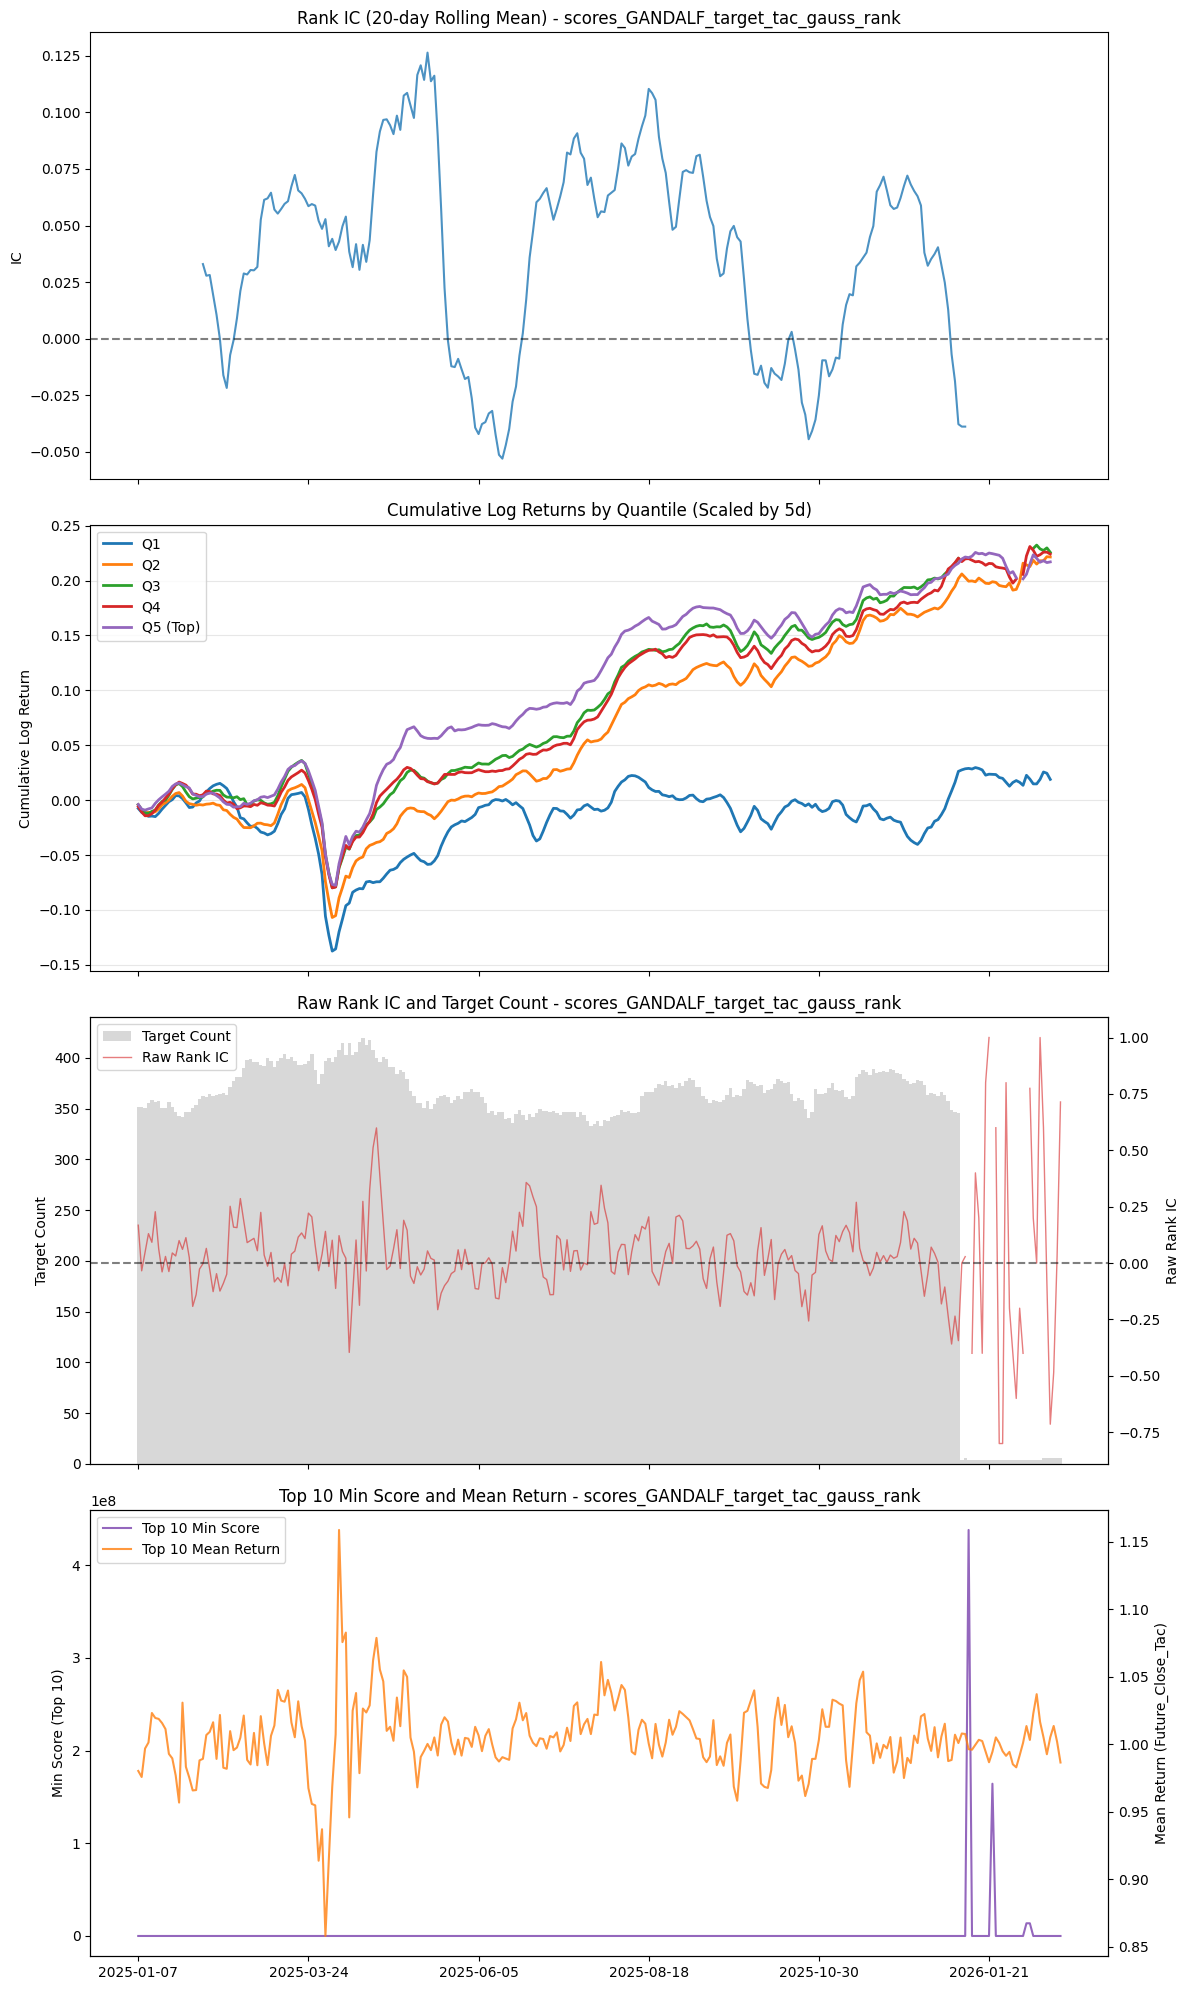

🏆 Calculating Top 10 Metrics for scores_LightGBM_target_tac_gauss_rank...


/var/folders/jk/b5tnwh1j1hq90nsy6xg8w2_h0000gn/T/ipykernel_82086/3563847720.py:26: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top10_metrics = df.groupby('date').apply(get_top10_metrics)


📊 Calculating Rank IC for scores_LightGBM_target_tac_gauss_rank...


/var/folders/jk/b5tnwh1j1hq90nsy6xg8w2_h0000gn/T/ipykernel_82086/3563847720.py:34: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  daily_ic = df.groupby('date').apply(calc_daily_ic)


  Mean IC: 0.1031
  ICIR:    0.3825
  t-stat:  6.3078 (p-value: 0.0000)
📈 Calculating Quantile Analysis (bins=5)...
✅ Plot saved to ./evaluation_plots/evaluation_scores_LightGBM_target_tac_gauss_rank.png


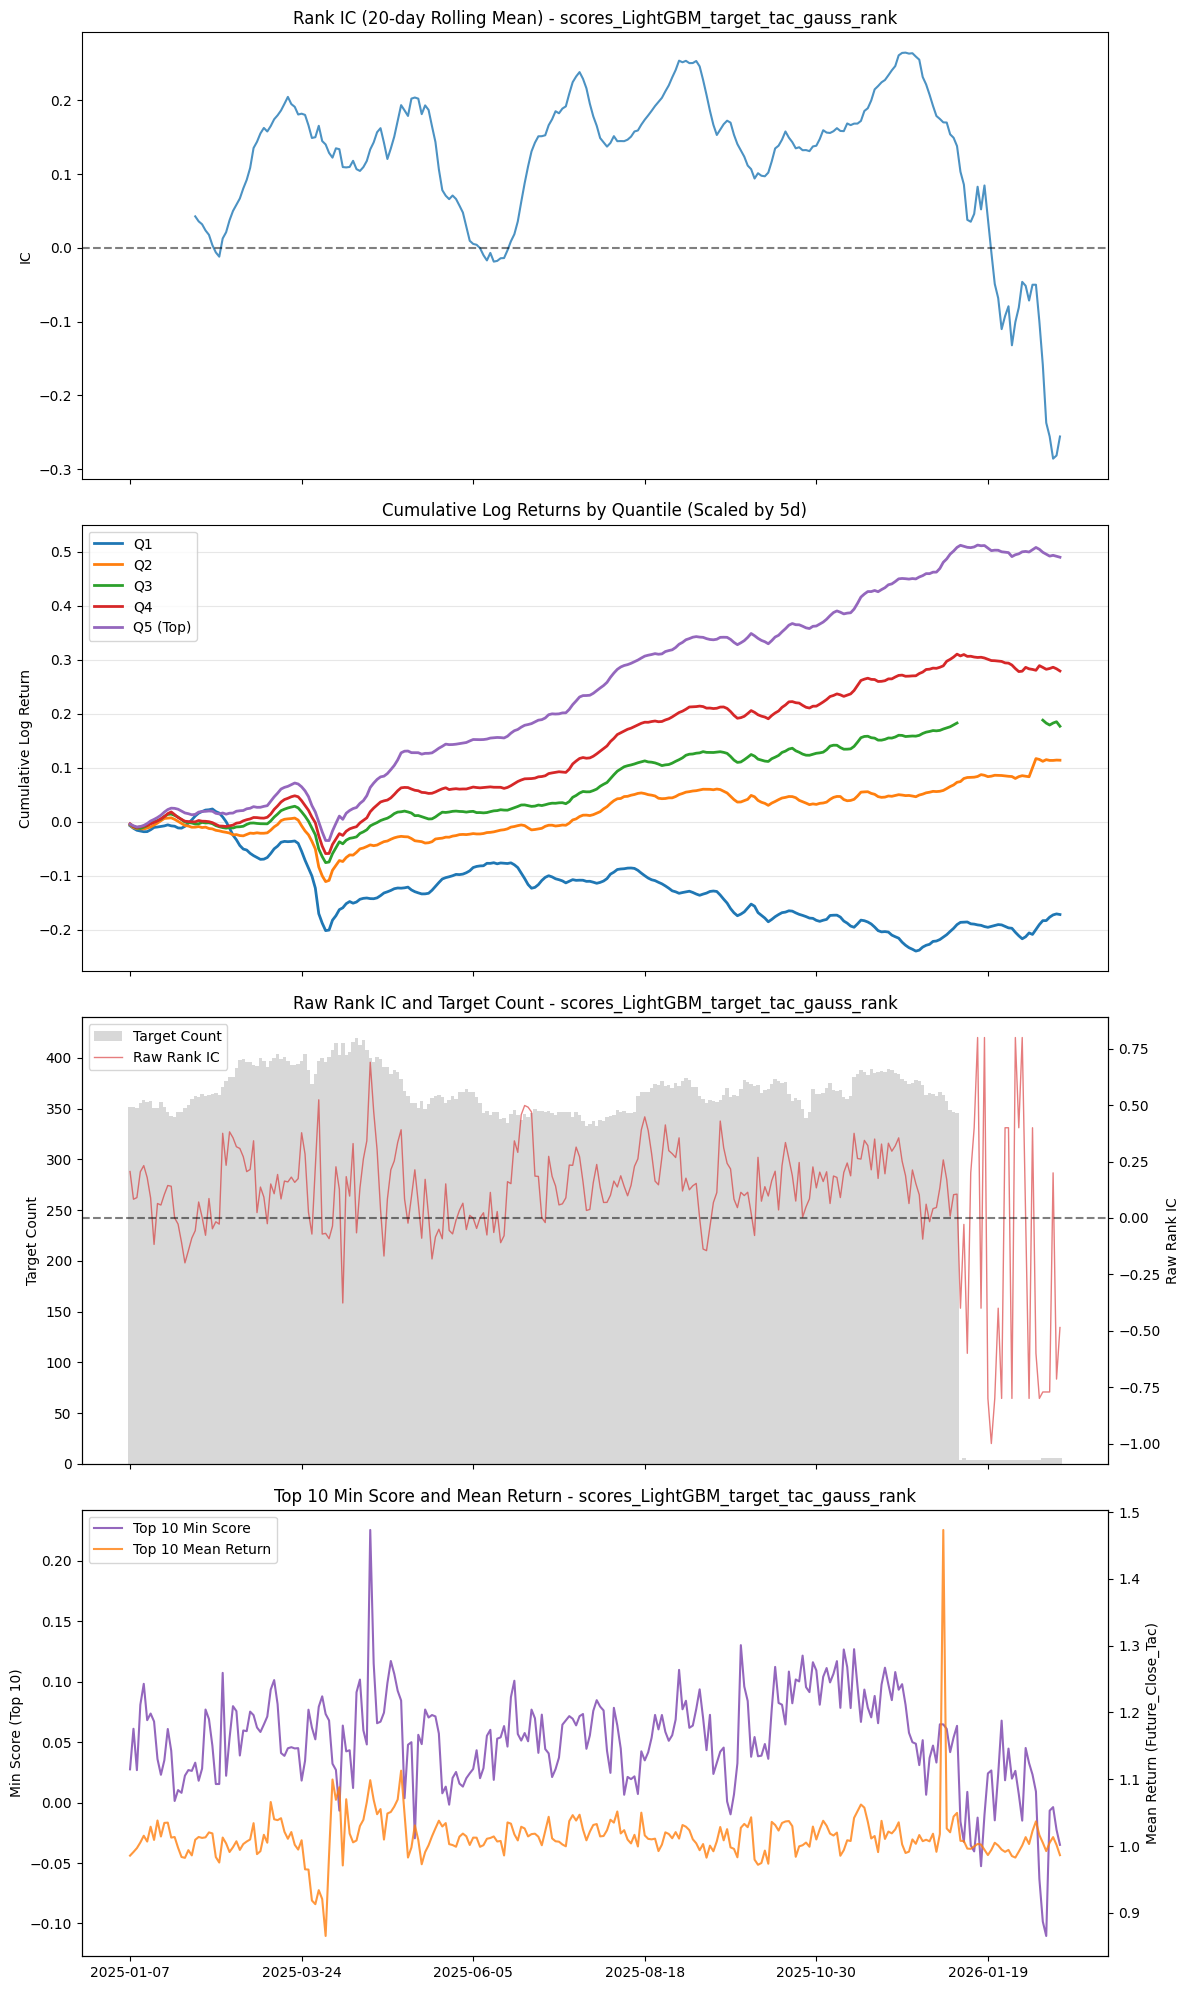

🏆 Calculating Top 10 Metrics for scores_LightGBM_target_tac_tb_strategy_a...


/var/folders/jk/b5tnwh1j1hq90nsy6xg8w2_h0000gn/T/ipykernel_82086/3563847720.py:26: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top10_metrics = df.groupby('date').apply(get_top10_metrics)


📊 Calculating Rank IC for scores_LightGBM_target_tac_tb_strategy_a...


/var/folders/jk/b5tnwh1j1hq90nsy6xg8w2_h0000gn/T/ipykernel_82086/3563847720.py:34: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  daily_ic = df.groupby('date').apply(calc_daily_ic)


  Mean IC: 0.0545
  ICIR:    0.2542
  t-stat:  4.1928 (p-value: 0.0000)
📈 Calculating Quantile Analysis (bins=5)...
✅ Plot saved to ./evaluation_plots/evaluation_scores_LightGBM_target_tac_tb_strategy_a.png


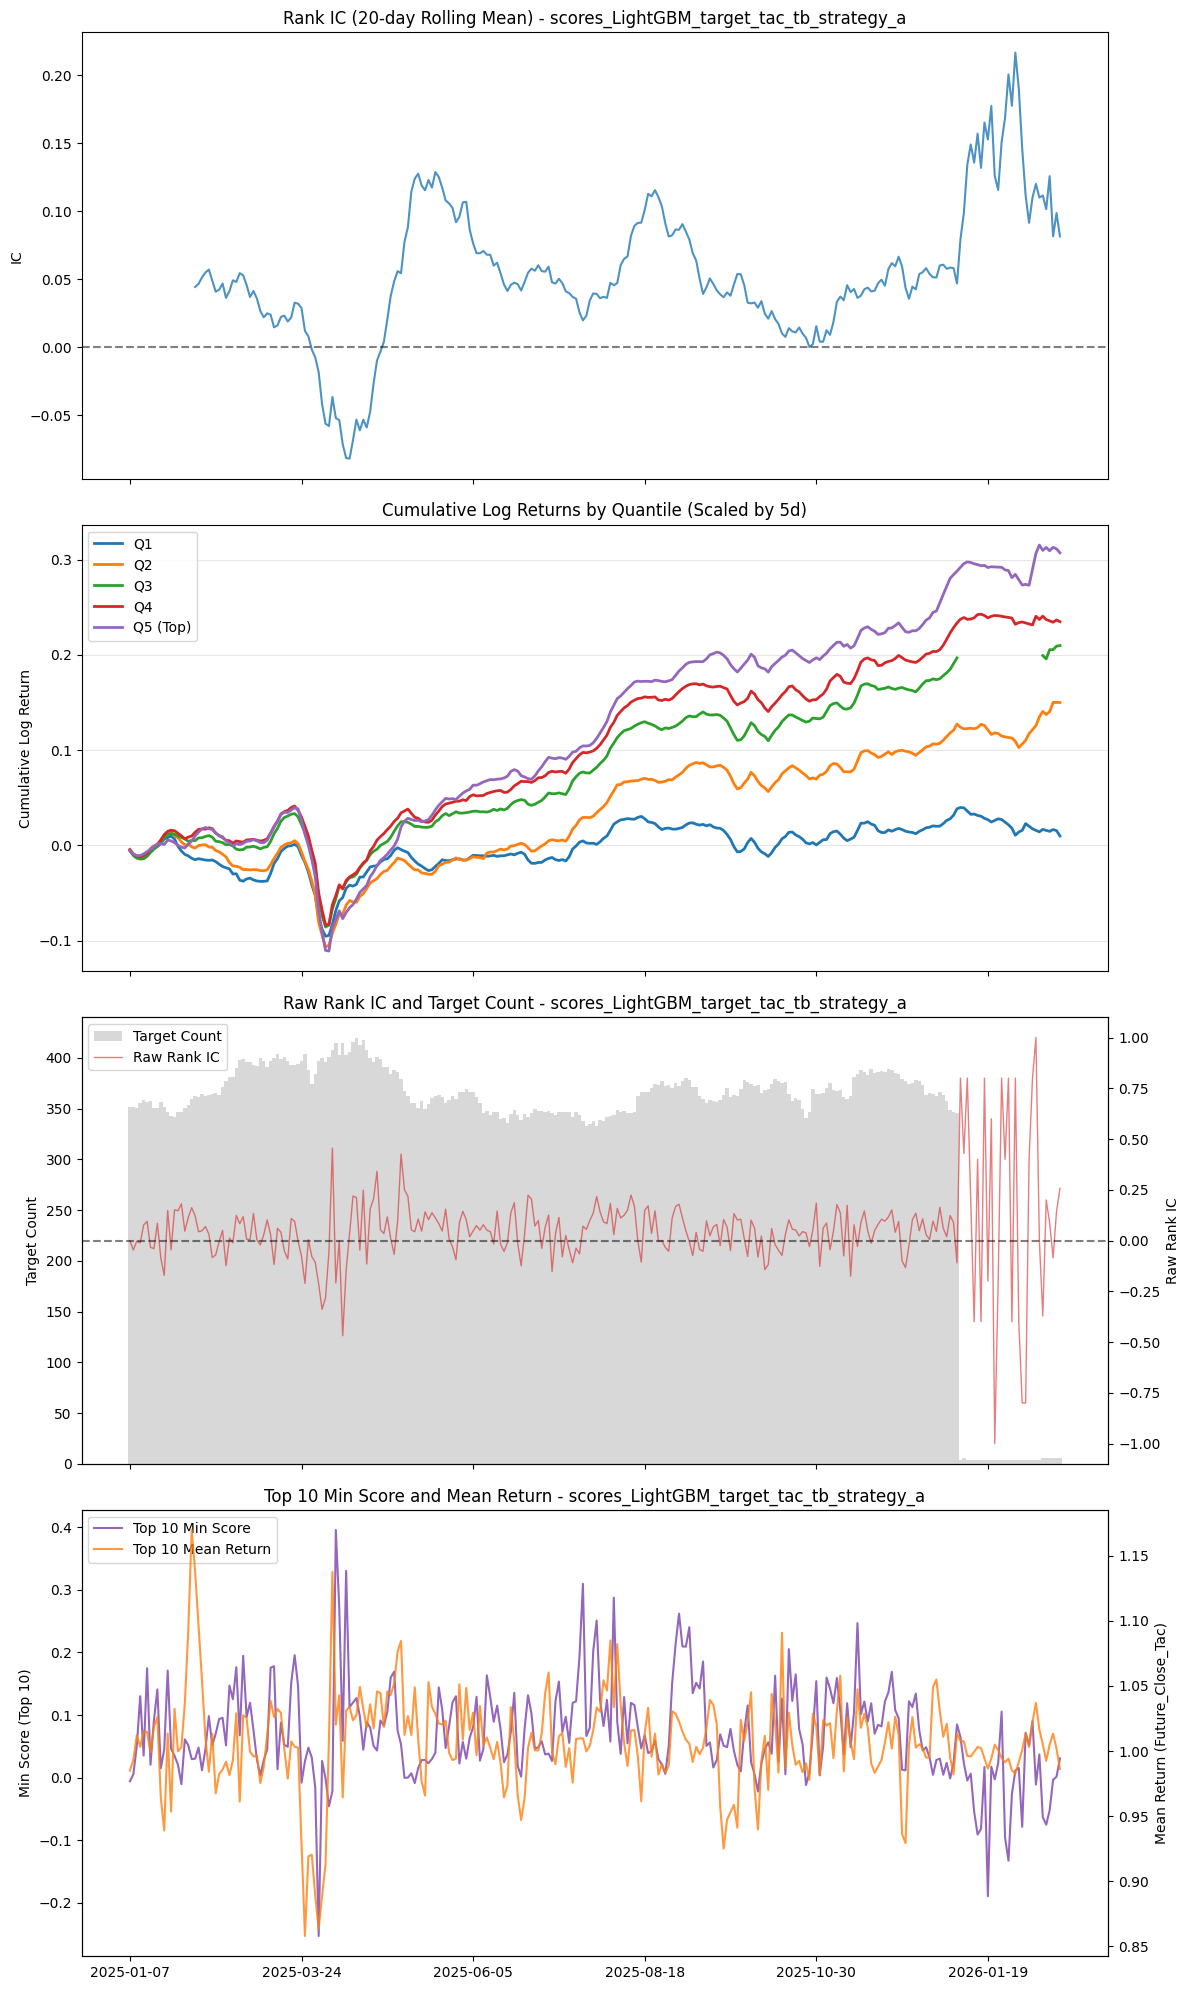

🏆 Calculating Top 10 Metrics for scores_TCN_target_tac_vol_scaled_residual...


/var/folders/jk/b5tnwh1j1hq90nsy6xg8w2_h0000gn/T/ipykernel_82086/3563847720.py:26: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top10_metrics = df.groupby('date').apply(get_top10_metrics)


📊 Calculating Rank IC for scores_TCN_target_tac_vol_scaled_residual...


/var/folders/jk/b5tnwh1j1hq90nsy6xg8w2_h0000gn/T/ipykernel_82086/3563847720.py:34: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  daily_ic = df.groupby('date').apply(calc_daily_ic)


  Mean IC: 0.0449
  ICIR:    0.1924
  t-stat:  3.1725 (p-value: 0.0017)
📈 Calculating Quantile Analysis (bins=5)...
✅ Plot saved to ./evaluation_plots/evaluation_scores_TCN_target_tac_vol_scaled_residual.png


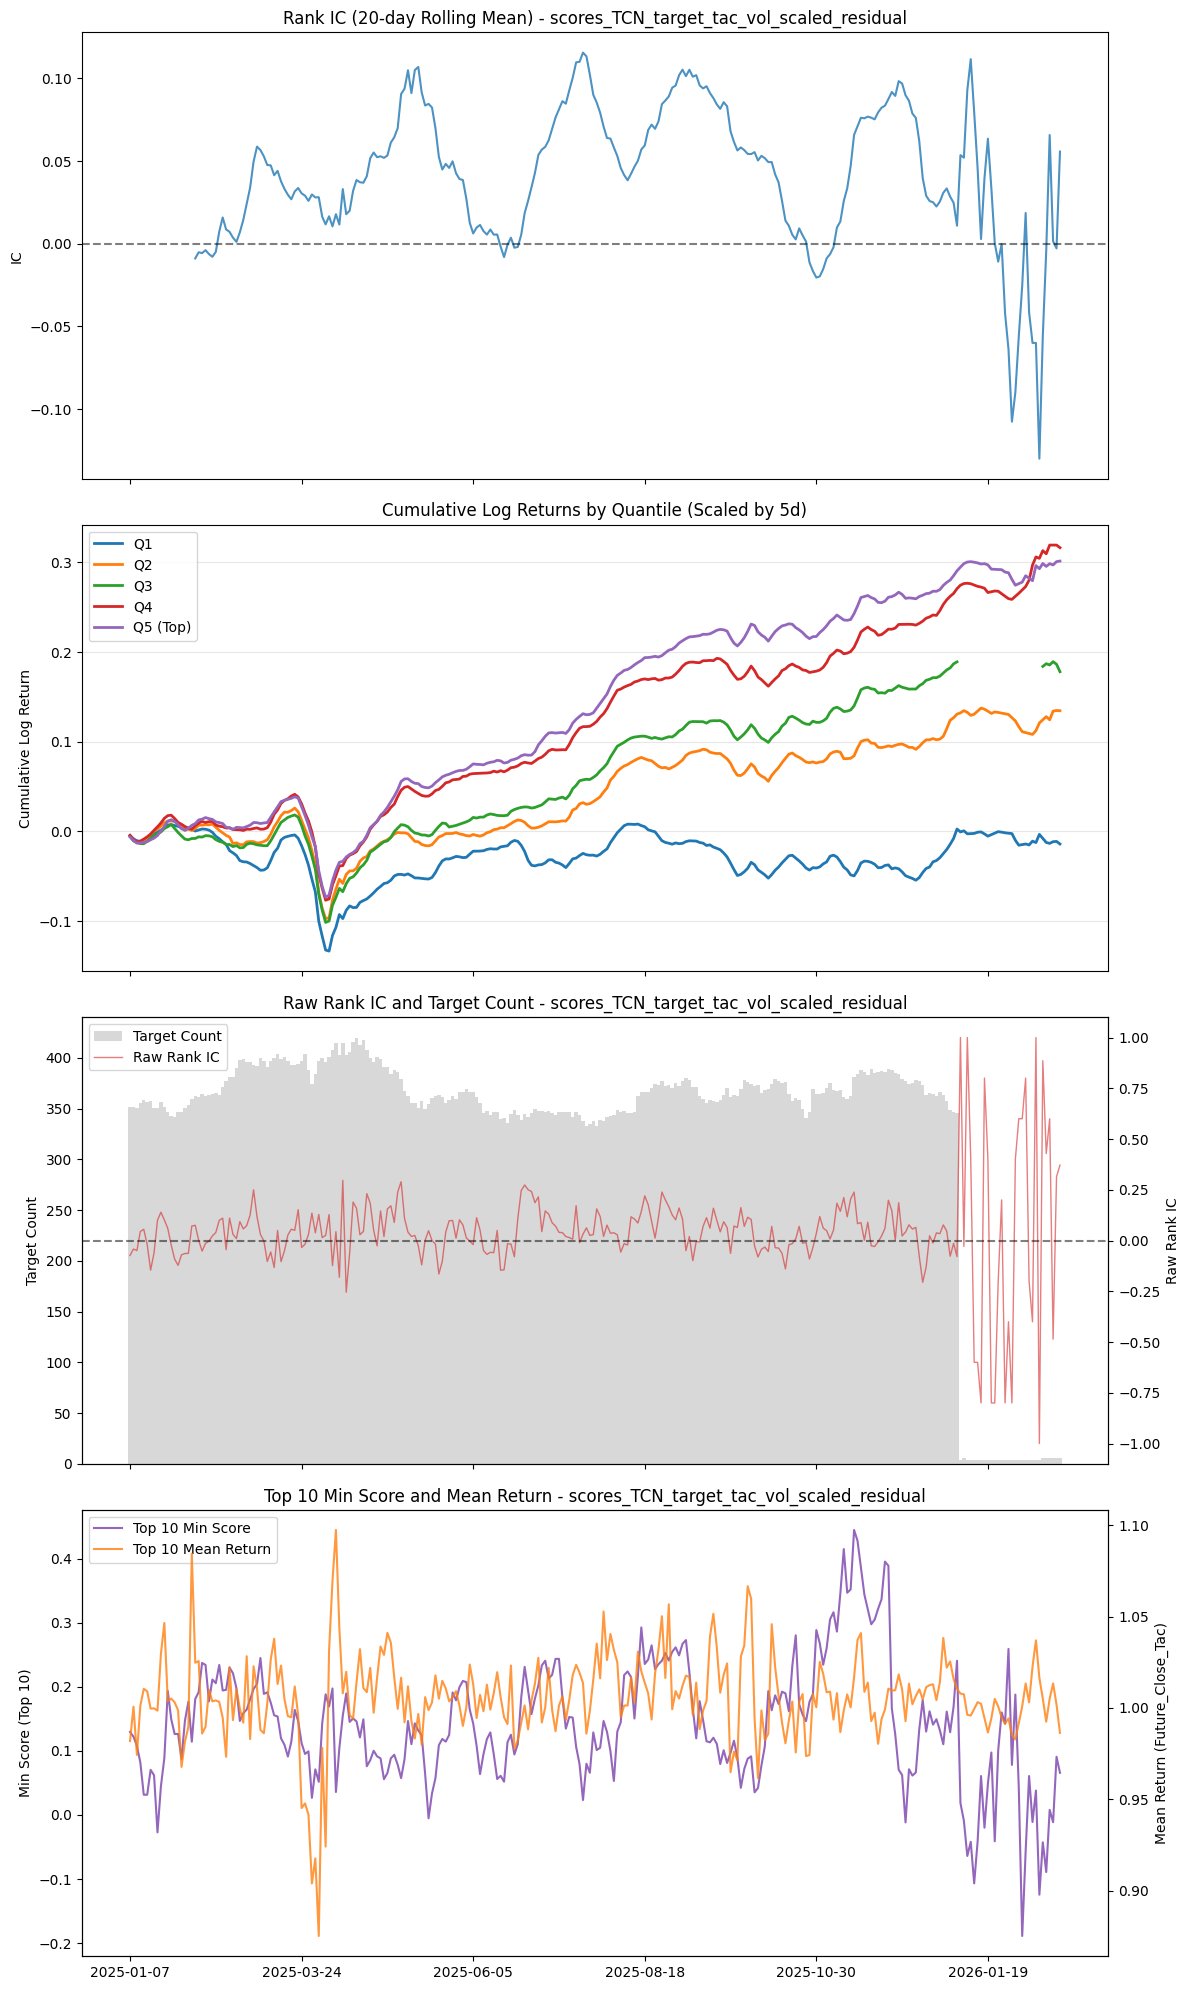

🏆 Calculating Top 10 Metrics for scores_TabNet_target_tac_gauss_rank...


/var/folders/jk/b5tnwh1j1hq90nsy6xg8w2_h0000gn/T/ipykernel_82086/3563847720.py:26: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top10_metrics = df.groupby('date').apply(get_top10_metrics)


📊 Calculating Rank IC for scores_TabNet_target_tac_gauss_rank...


/var/folders/jk/b5tnwh1j1hq90nsy6xg8w2_h0000gn/T/ipykernel_82086/3563847720.py:34: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  daily_ic = df.groupby('date').apply(calc_daily_ic)


  Mean IC: 0.0282
  ICIR:    0.1106
  t-stat:  1.8249 (p-value: 0.0691)
📈 Calculating Quantile Analysis (bins=5)...
✅ Plot saved to ./evaluation_plots/evaluation_scores_TabNet_target_tac_gauss_rank.png


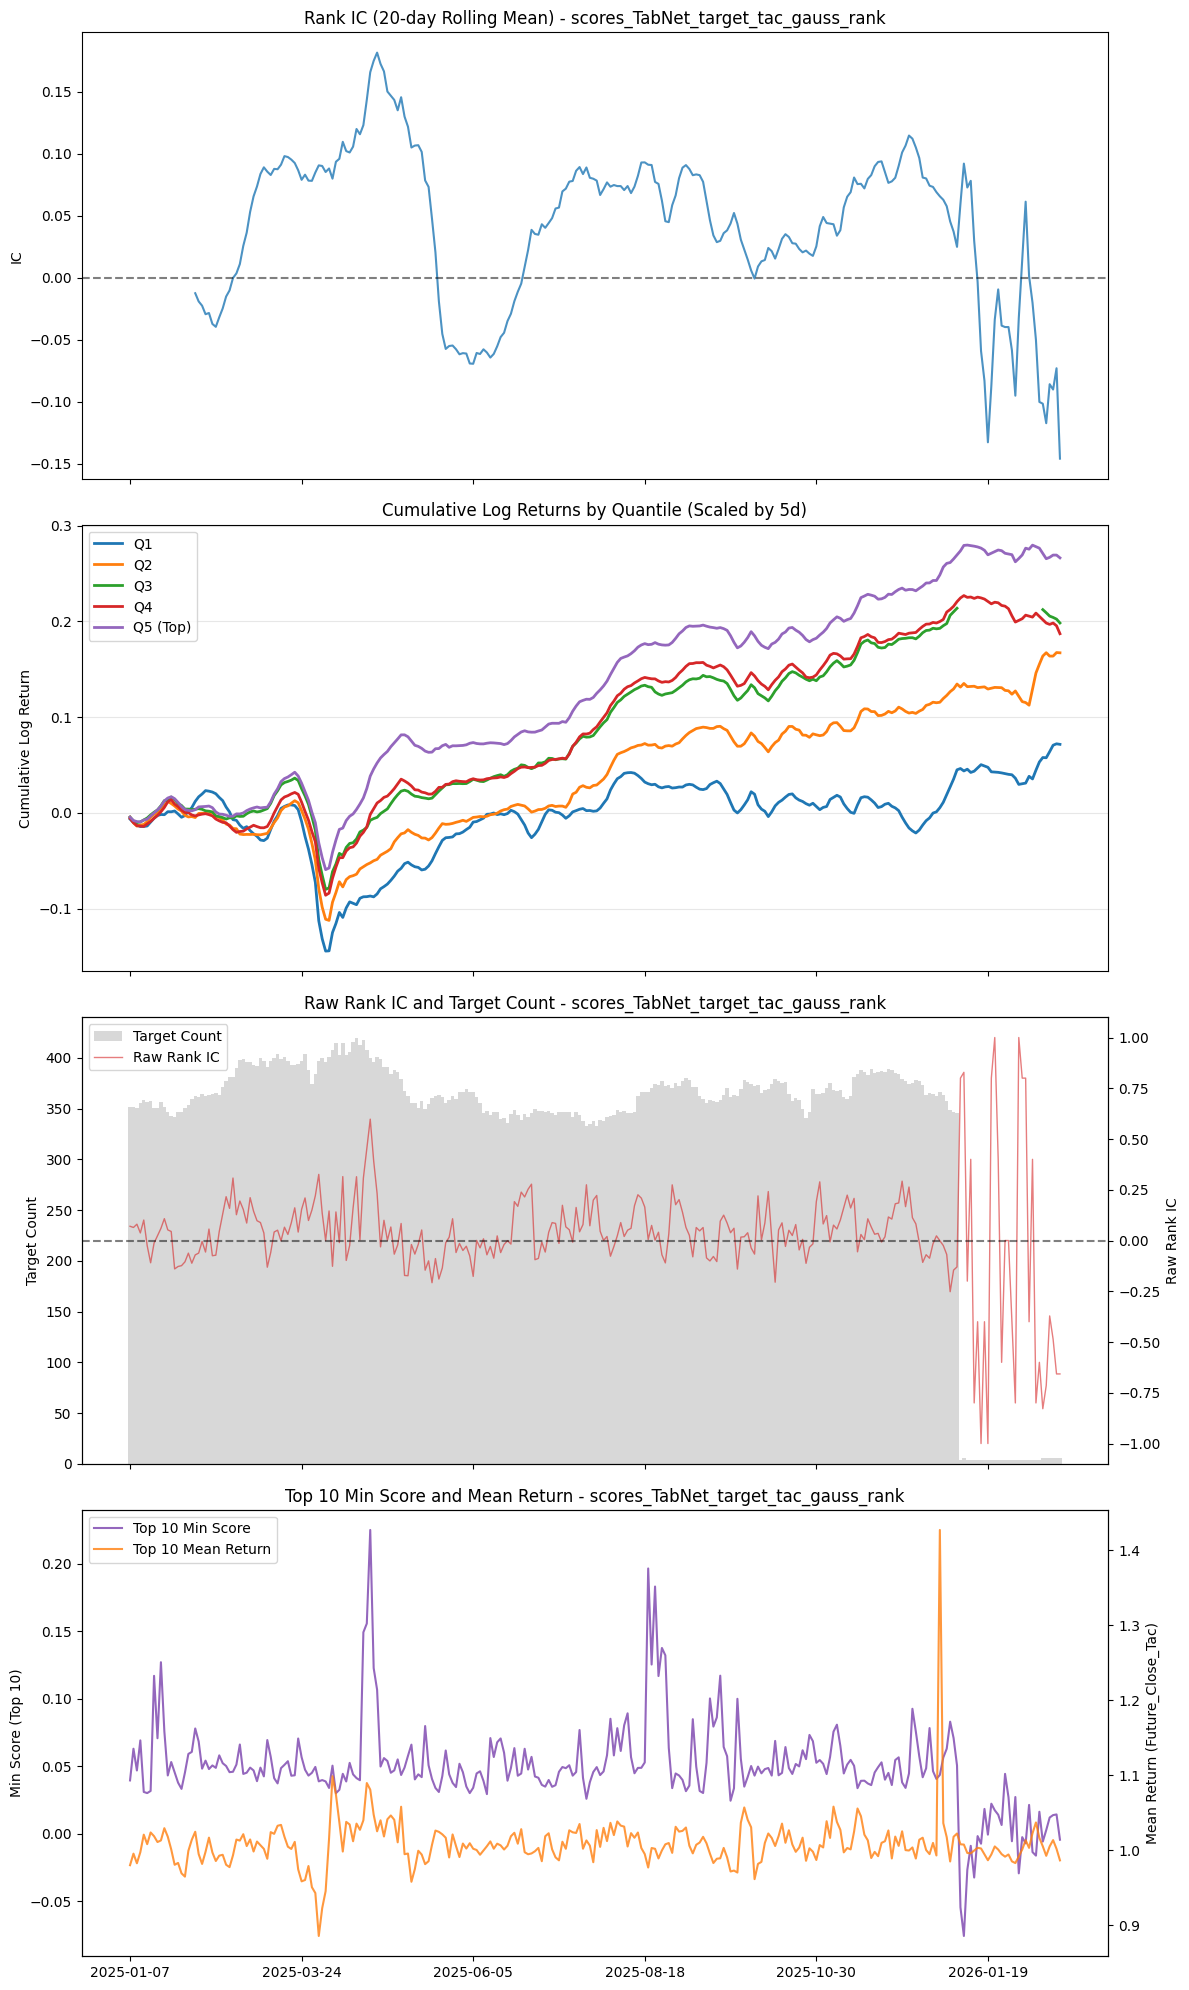

🏆 Calculating Top 10 Metrics for scores_GANDALF_target_str_gauss_rank...


/var/folders/jk/b5tnwh1j1hq90nsy6xg8w2_h0000gn/T/ipykernel_82086/3563847720.py:26: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top10_metrics = df.groupby('date').apply(get_top10_metrics)


📊 Calculating Rank IC for scores_GANDALF_target_str_gauss_rank...


/var/folders/jk/b5tnwh1j1hq90nsy6xg8w2_h0000gn/T/ipykernel_82086/3563847720.py:34: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  daily_ic = df.groupby('date').apply(calc_daily_ic)


  Mean IC: 0.1745
  ICIR:    1.0847
  t-stat:  17.8900 (p-value: 0.0000)
📈 Calculating Quantile Analysis (bins=5)...
✅ Plot saved to ./evaluation_plots/evaluation_scores_GANDALF_target_str_gauss_rank.png


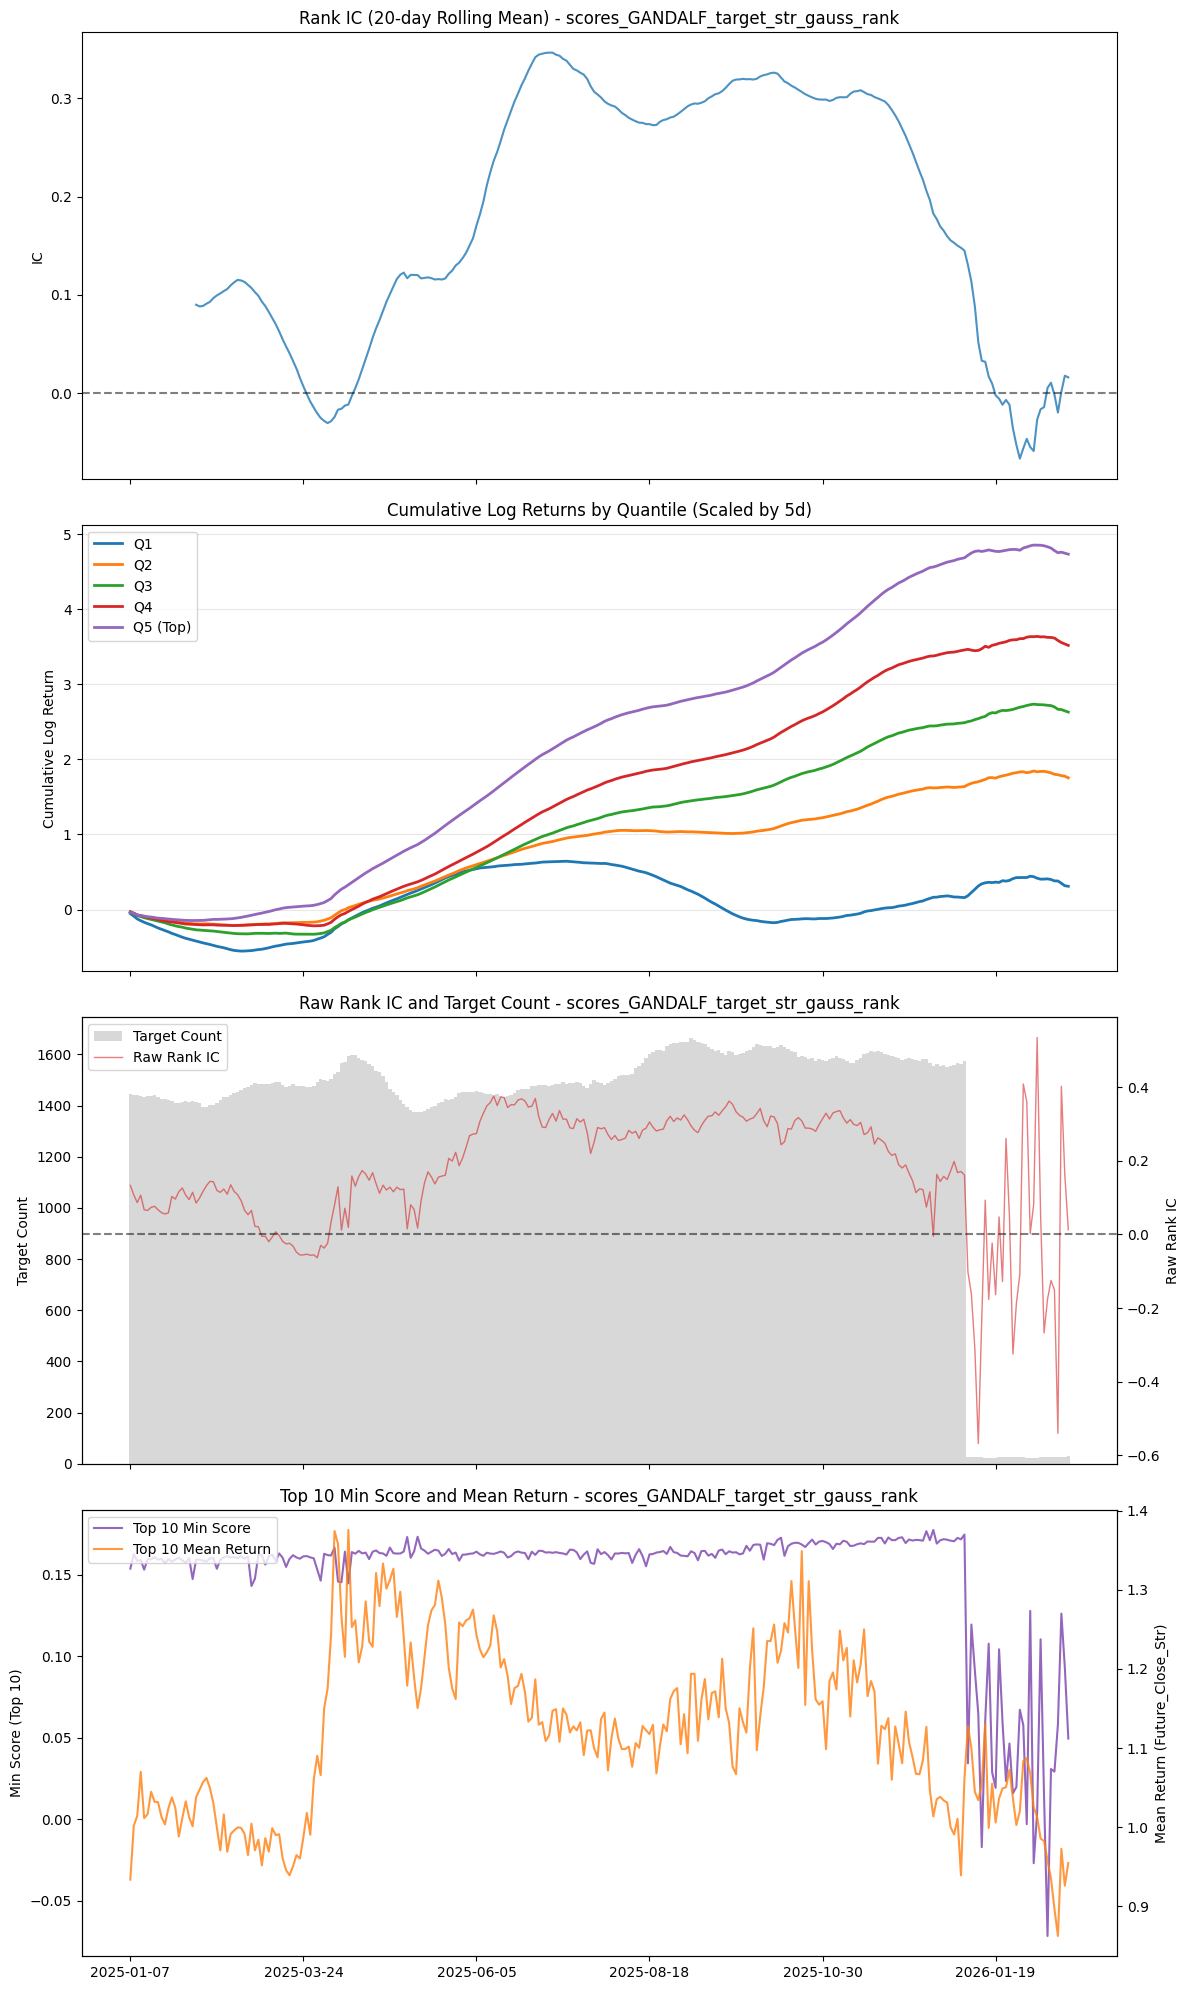

🏆 Calculating Top 10 Metrics for scores_LightGBM_target_str_gauss_rank...


/var/folders/jk/b5tnwh1j1hq90nsy6xg8w2_h0000gn/T/ipykernel_82086/3563847720.py:26: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top10_metrics = df.groupby('date').apply(get_top10_metrics)


📊 Calculating Rank IC for scores_LightGBM_target_str_gauss_rank...


/var/folders/jk/b5tnwh1j1hq90nsy6xg8w2_h0000gn/T/ipykernel_82086/3563847720.py:34: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  daily_ic = df.groupby('date').apply(calc_daily_ic)


  Mean IC: 0.2638
  ICIR:    1.5376
  t-stat:  25.3589 (p-value: 0.0000)
📈 Calculating Quantile Analysis (bins=5)...
✅ Plot saved to ./evaluation_plots/evaluation_scores_LightGBM_target_str_gauss_rank.png


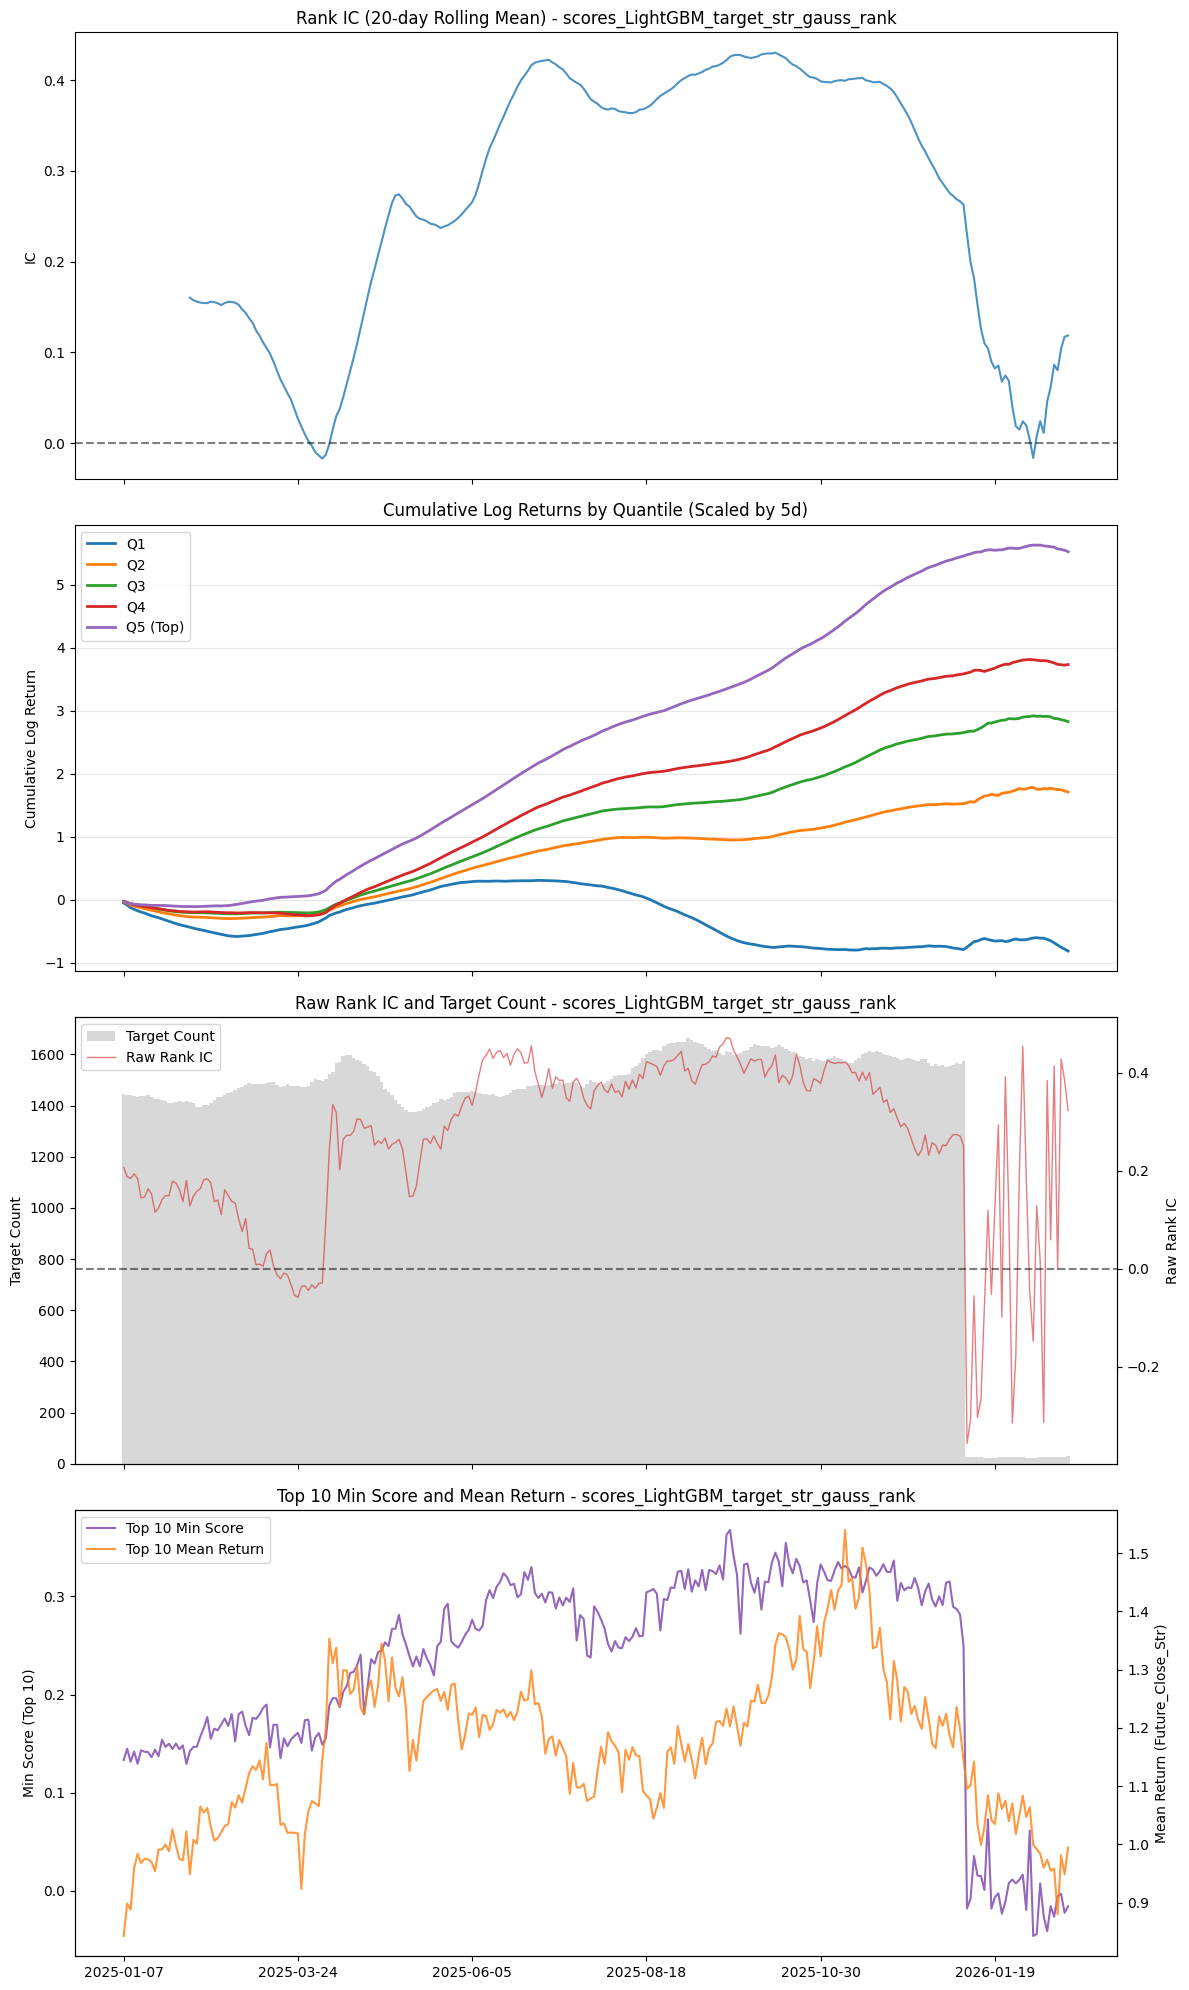

🏆 Calculating Top 10 Metrics for scores_LightGBM_target_str_triple_barrier...


/var/folders/jk/b5tnwh1j1hq90nsy6xg8w2_h0000gn/T/ipykernel_82086/3563847720.py:26: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top10_metrics = df.groupby('date').apply(get_top10_metrics)


📊 Calculating Rank IC for scores_LightGBM_target_str_triple_barrier...


/var/folders/jk/b5tnwh1j1hq90nsy6xg8w2_h0000gn/T/ipykernel_82086/3563847720.py:34: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  daily_ic = df.groupby('date').apply(calc_daily_ic)


  Mean IC: 0.1955
  ICIR:    1.0921
  t-stat:  18.0112 (p-value: 0.0000)
📈 Calculating Quantile Analysis (bins=5)...
✅ Plot saved to ./evaluation_plots/evaluation_scores_LightGBM_target_str_triple_barrier.png


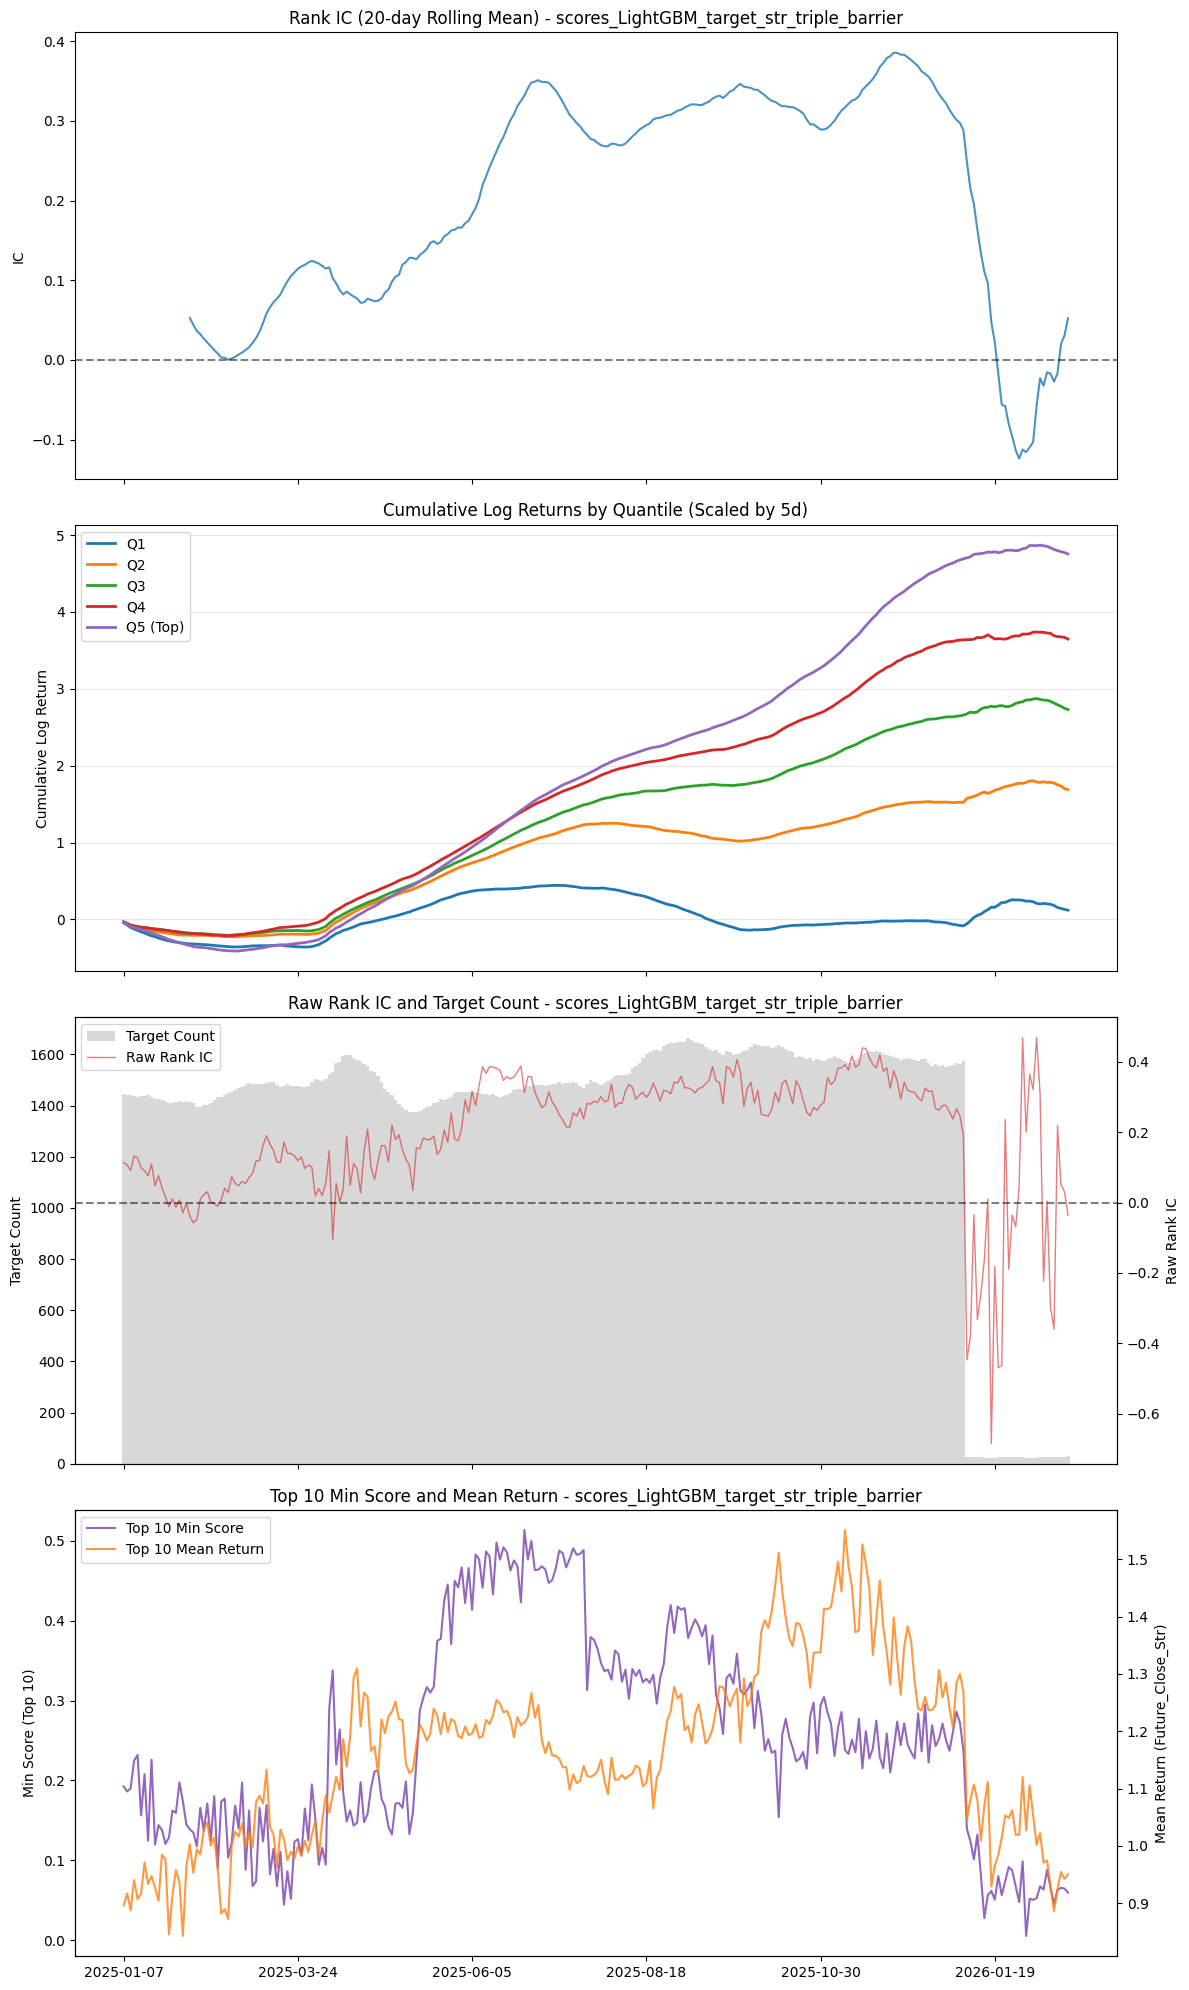

🏆 Calculating Top 10 Metrics for scores_TabNet_target_str_gauss_rank...


/var/folders/jk/b5tnwh1j1hq90nsy6xg8w2_h0000gn/T/ipykernel_82086/3563847720.py:26: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top10_metrics = df.groupby('date').apply(get_top10_metrics)


📊 Calculating Rank IC for scores_TabNet_target_str_gauss_rank...


/var/folders/jk/b5tnwh1j1hq90nsy6xg8w2_h0000gn/T/ipykernel_82086/3563847720.py:34: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  daily_ic = df.groupby('date').apply(calc_daily_ic)


  Mean IC: 0.1673
  ICIR:    1.1502
  t-stat:  18.9704 (p-value: 0.0000)
📈 Calculating Quantile Analysis (bins=5)...
✅ Plot saved to ./evaluation_plots/evaluation_scores_TabNet_target_str_gauss_rank.png


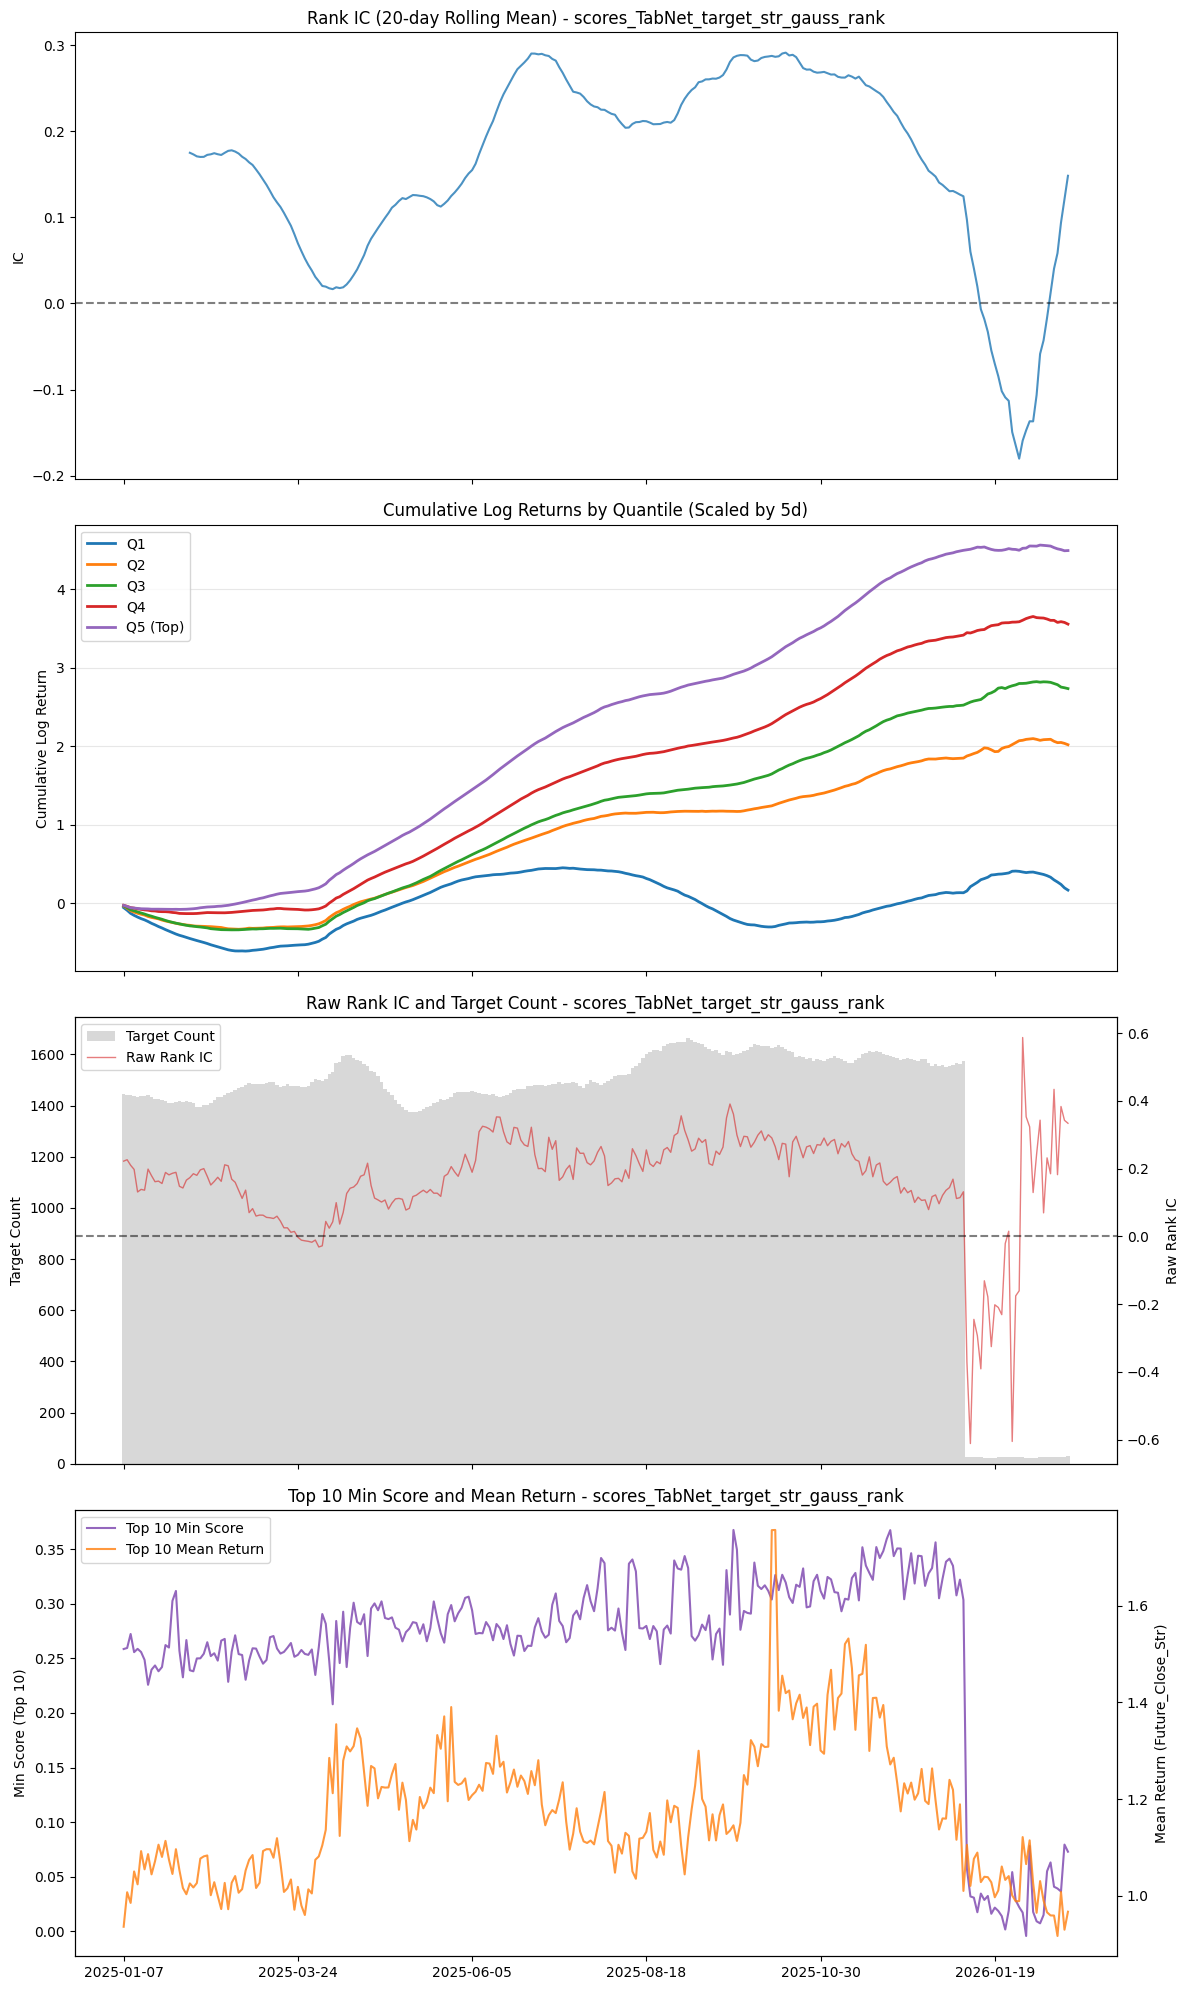

In [37]:
scores_tac = [x for x in df.columns if x.find('scores_')!=-1 and x.find('_tac_')!=-1]
scores_str = [x for x in df.columns if x.find('scores_')!=-1 and x.find('_str_')!=-1]

for score in scores_tac: 
    res = evaluate_model_performance(
        df, 
        score_col=score,
        target_col='Future_Close_Tac', 
        horizon=5,
        save_dir='./evaluation_plots'
    )
    res.to_csv('results_'+score+'.csv',index=False)

for score in scores_str: 
    res = evaluate_model_performance(
        df, 
        score_col=score,
        target_col='Future_Close_Str', 
        horizon=5,
        save_dir='./evaluation_plots'
    )
    res.to_csv('results_'+score+'.csv',index=False)

In [23]:
res


,date,target_count,daily_ic,cum_log_ret_Q1,cum_log_ret_Q2,cum_log_ret_Q3,cum_log_ret_Q4,cum_log_ret_Q5
0,2025-01-07,1444,0.145160,-0.006936,-0.006362,-0.004610,-0.004377,-0.004515
1,2025-01-08,1443,0.098960,-0.012799,-0.011160,-0.008489,-0.008368,-0.008038
2,2025-01-09,1441,0.174904,-0.017381,-0.014369,-0.010770,-0.010432,-0.009335
3,2025-01-10,1438,0.162164,-0.018830,-0.014658,-0.010909,-0.010111,-0.008247
4,2025-01-14,1433,0.091931,-0.018582,-0.013103,-0.009755,-0.008585,-0.006194
...,...,...,...,...,...,...,...,...
267,2026-02-12,28,-0.461412,-0.052535,0.082693,0.205796,0.291428,0.422446
268,2026-02-13,28,-0.251779,-0.045542,0.089449,0.194602,0.289477,0.431846
269,2026-02-16,28,-0.180624,-0.042719,0.081891,0.199437,0.292922,0.429782
270,2026-02-17,28,0.077460,-0.061610,0.084408,0.202285,0.294143,0.424872


## Bin分析

In [33]:
target = 'scores_TabNet_target_tac_gauss_rank'
domain = 'TAC'

calc = df.dropna(subset=[target])
calc['score_bin'] = pd.qcut(calc[target],100)

out = calc.groupby('score_bin').size().to_frame(name='cnt')
d = calc[['score_bin','Future_High_Tac']].groupby('score_bin').agg(['median']).values
_out = pd.DataFrame(d,index=out.index,columns=['High_med'])
out = out.join(_out)
d = calc[['score_bin','Future_Low_Tac']].groupby('score_bin').agg(['median']).values
_out = pd.DataFrame(d,index=out.index,columns=['Low_med'])
out = out.join(_out)
d = calc[['score_bin','Future_Close_Tac']].groupby('score_bin').describe().values[:,1:]
_out = pd.DataFrame(d,index=out.index,columns=['Close_ave','Close_std','min','p25','p50','p75','max'])
out = out.join(_out)
out


/var/folders/jk/b5tnwh1j1hq90nsy6xg8w2_h0000gn/T/ipykernel_82086/3791472131.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  calc['score_bin'] = pd.qcut(calc[target],100)
/var/folders/jk/b5tnwh1j1hq90nsy6xg8w2_h0000gn/T/ipykernel_82086/3791472131.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  out = calc.groupby('score_bin').size().to_frame(name='cnt')
/var/folders/jk/b5tnwh1j1hq90nsy6xg8w2_h0000gn/T/ipykernel_82086/3791472131.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pa

,cnt,High_med,Low_med,Close_ave,Close_std,min,p25,p50,p75,max
score_bin,,,,,,,,,,
"(-0.40700000000000003, -0.123]",893,1.066207,0.933071,0.996380,0.131169,0.547664,0.920348,0.981536,1.054479,1.846984
"(-0.123, -0.0897]",892,1.042750,0.945973,0.993856,0.116218,0.498462,0.931330,0.985421,1.036827,1.894944
"(-0.0897, -0.0699]",892,1.043344,0.956351,1.003498,0.105475,0.628910,0.954955,0.994686,1.039843,2.578815
"(-0.0699, -0.0579]",892,1.039828,0.964394,1.005265,0.081866,0.676373,0.963605,1.002966,1.041670,1.531999
"(-0.0579, -0.0494]",893,1.033719,0.966397,1.001843,0.078220,0.728329,0.964474,0.998195,1.035760,1.621234
...,...,...,...,...,...,...,...,...,...,...
"(0.0509, 0.0549]",893,1.021407,0.984203,1.006441,0.038602,0.803491,0.987709,1.005365,1.023789,1.288846
"(0.0549, 0.0603]",892,1.021058,0.984004,1.012783,0.145036,0.793546,0.988255,1.005996,1.023108,5.195312
"(0.0603, 0.0695]",892,1.021052,0.981876,1.006841,0.039801,0.864937,0.983658,1.004657,1.025053,1.267776


## Top Hit

In [34]:
target = 'scores_TabNet_target_tac_gauss_rank'
domain = 'TAC'

calc = df.dropna(subset=[target])
calc

,date,scode,Future_High_Tac,Future_Low_Tac,Future_Close_Tac,Future_High_Str,Future_Low_Str,Future_Close_Str,scores_GANDALF_target_str_gauss_rank,scores_GANDALF_target_tac_gauss_rank,scores_LightGBM_target_str_gauss_rank,scores_LightGBM_target_str_triple_barrier,scores_LightGBM_target_tac_gauss_rank,scores_LightGBM_target_tac_tb_strategy_a,scores_TCN_target_tac_vol_scaled_residual,scores_TabNet_target_str_gauss_rank,scores_TabNet_target_tac_gauss_rank
938,2025-01-07,1942,1.044833,0.989539,1.000000,1.216482,0.926986,1.058070,-0.120741,0.028854,-0.086165,-0.144472,-0.014317,-0.158961,-0.015660,-0.046597,0.007177
939,2025-01-08,1942,1.021712,0.967641,0.974739,1.189562,0.906472,1.072234,-0.049282,-0.050070,-0.076298,-0.144162,0.028783,-0.066864,-0.008683,-0.063082,0.022867
940,2025-01-09,1942,1.008882,0.935550,0.953109,1.177029,0.896922,1.054121,-0.108492,-0.048541,-0.076349,-0.146845,-0.024650,-0.029364,0.044465,-0.065903,-0.004717
941,2025-01-10,1942,1.001659,0.939042,0.969314,1.181422,0.900270,1.102218,-0.101360,0.006375,-0.032157,-0.088466,0.038523,0.035870,-0.033153,-0.049179,0.035783
942,2025-01-14,1942,1.017167,0.971888,0.998069,1.222747,0.931760,1.133262,-0.102957,0.032537,-0.038477,-0.091748,0.047449,-0.042109,-0.157126,-0.055113,0.010374
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1007799,2026-01-05,5817,1.022500,0.822500,0.853333,2.147500,0.822500,1.106667,-0.142730,-0.102794,-0.340150,0.081954,-0.200913,0.072542,0.208927,-0.326936,-0.081395
1007805,2026-01-05,9107,1.058100,0.998861,1.051492,1.350877,0.983367,1.229437,0.024474,0.043999,0.088206,-0.041145,0.029098,0.022127,0.201200,0.049748,0.018924
1007872,2026-01-05,3287,1.018978,0.996127,1.007359,1.061967,0.935709,0.980248,-0.031446,0.037569,-0.000322,0.049188,-0.012461,-0.009116,0.168513,-0.047339,0.016505
1007943,2026-01-05,3099,1.097822,0.988894,1.087142,1.390431,0.988894,1.304143,-0.002368,0.028959,0.019983,-0.065529,-0.011643,0.013287,0.128209,0.009931,-0.002498


In [35]:
calc.groupby('date').head()

,date,scode,Future_High_Tac,Future_Low_Tac,Future_Close_Tac,Future_High_Str,Future_Low_Str,Future_Close_Str,scores_GANDALF_target_str_gauss_rank,scores_GANDALF_target_tac_gauss_rank,scores_LightGBM_target_str_gauss_rank,scores_LightGBM_target_str_triple_barrier,scores_LightGBM_target_tac_gauss_rank,scores_LightGBM_target_tac_tb_strategy_a,scores_TCN_target_tac_vol_scaled_residual,scores_TabNet_target_str_gauss_rank,scores_TabNet_target_tac_gauss_rank
938,2025-01-07,1942,1.044833,0.989539,1.000000,1.216482,0.926986,1.058070,-0.120741,0.028854,-0.086165,-0.144472,-0.014317,-0.158961,-0.015660,-0.046597,0.007177
939,2025-01-08,1942,1.021712,0.967641,0.974739,1.189562,0.906472,1.072234,-0.049282,-0.050070,-0.076298,-0.144162,0.028783,-0.066864,-0.008683,-0.063082,0.022867
940,2025-01-09,1942,1.008882,0.935550,0.953109,1.177029,0.896922,1.054121,-0.108492,-0.048541,-0.076349,-0.146845,-0.024650,-0.029364,0.044465,-0.065903,-0.004717
941,2025-01-10,1942,1.001659,0.939042,0.969314,1.181422,0.900270,1.102218,-0.101360,0.006375,-0.032157,-0.088466,0.038523,0.035870,-0.033153,-0.049179,0.035783
942,2025-01-14,1942,1.017167,0.971888,0.998069,1.222747,0.931760,1.133262,-0.102957,0.032537,-0.038477,-0.091748,0.047449,-0.042109,-0.157126,-0.055113,0.010374
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1004789,2026-02-13,2432,1.000911,0.959176,0.982686,1.038819,0.876982,0.887917,-0.017955,-0.005267,-0.009829,0.052353,0.016375,0.022566,0.226812,-0.005028,0.020888
1004791,2026-02-16,2432,1.012015,0.972828,0.992976,1.053605,0.889464,0.930499,0.132720,0.012520,0.116181,0.075207,-0.003701,0.022632,0.306575,0.087548,0.028404
1004793,2026-02-17,2432,1.027397,0.983111,1.000000,1.069619,0.902984,0.932445,0.028398,-0.074146,-0.024406,0.032794,0.010501,0.009398,0.394737,-0.003991,0.048138
1004795,2026-02-18,2432,1.012576,0.968929,0.985574,1.054189,0.889957,0.946921,0.064228,-0.134994,0.039904,0.073420,0.006104,0.040198,0.294587,0.028685,0.036947
